<a href="https://colab.research.google.com/github/MAINISHA/fuzzy-churn/blob/main/European_bank_churn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Churn Prediction Model for a European Bank

This notebook develops and evaluates machine learning models to predict customer churn for a European bank. It covers data loading, preprocessing, feature engineering, model training (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost), comprehensive model evaluation, and interpretation using SHAP values and Partial Dependence Plots.

In [1]:
!pip install -q xgboost shap

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
RANDOM_STATE = 42 # Define RANDOM_STATE


## 1. Setup and Imports

This section imports necessary libraries and sets up basic configurations for the notebook.

<!-- This is a duplicate heading for section 5.5 and has been commented out. The actual section 5.5 is placed correctly after section 5.4. -->

In [3]:
from google.colab import files

uploaded = files.upload()  # select European_Bank.csv when prompted
DATA_PATH = "European_Bank.csv"

df = pd.read_csv(DATA_PATH) # Load the dataframe
print(df.shape)
df.head()


Saving European_Bank.csv to European_Bank.csv
(10000, 14)


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 2. Data Loading and Initial Exploration

This section focuses on loading the dataset and performing initial checks to understand its structure, identify missing values, and observe target distribution.

In [4]:
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nTarget distribution (Exited):")
print(df['Exited'].value_counts(normalize=True).round(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

Missing values per column:
Year               0
CustomerId         0
Surname            0
Cre

## 3. Data Preprocessing and Feature Engineering

This section covers all steps taken to clean, transform, and enhance the raw data, preparing it for machine learning models. It includes handling missing values, feature engineering, encoding categorical variables, and splitting the data for training and testing.

### 3.1 Handling Raw Data

This sub-section addresses data quality by handling missing values and dropping columns that are non-informative or redundant for the prediction task.

In [5]:
data = df.copy() # Initialize data from df

# Handle missing values (robust even if none currently exist)
num_cols_all = data.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_all = data.select_dtypes(include=['object']).columns.tolist()

for c in num_cols_all:
    if data[c].isnull().any():
        data[c] = data[c].fillna(data[c].median())

for c in cat_cols_all:
    if data[c].isnull().any():
        data[c] = data[c].fillna(data[c].mode()[0])

# Drop non-informative features
drop_cols = [c for c in ['CustomerId', 'Surname'] if c in data.columns]
constant_cols = [c for c in data.columns if data[c].nunique() == 1]
drop_cols += [c for c in constant_cols if c not in drop_cols]

print("Dropping columns:", drop_cols)
data = data.drop(columns=drop_cols)
data.head()


Dropping columns: ['CustomerId', 'Surname', 'Year']


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### 3.2 Feature Engineering

New features are created from existing ones to potentially capture more complex relationships and improve model performance.

In [6]:
eps = 1  # avoid division-by-zero

data['BalanceSalaryRatio'] = data['Balance'] / (data['EstimatedSalary'] + eps)
data['ProductDensity'] = data['NumOfProducts'] / (data['Tenure'] + eps)
data['EngagementProductInteraction'] = data['IsActiveMember'] * data['NumOfProducts']
data['AgeTenureInteraction'] = data['Age'] * data['Tenure']
data['HasBalance'] = (data['Balance'] > 0).astype(int)
data['CreditScoreAgeRatio'] = data['CreditScore'] / (data['Age'] + eps)

data.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,ProductDensity,EngagementProductInteraction,AgeTenureInteraction,HasBalance,CreditScoreAgeRatio
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,0.333333,1,84,0,14.395349
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744670,0.500000,1,41,1,14.476190
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401362,0.333333,0,336,1,11.674419
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000,1.000000,0,39,0,17.475000
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587035,0.333333,1,86,1,19.318182


### 3.3 One-Hot Encoding Categorical Variables

Categorical features are converted into a numerical format suitable for machine learning models using one-hot encoding.

In [7]:
categorical_cols = ['Geography', 'Gender']
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

print(data.shape)
data.head()


(10000, 18)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,ProductDensity,EngagementProductInteraction,AgeTenureInteraction,HasBalance,CreditScoreAgeRatio,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0.000000,0.333333,1,84,0,14.395349,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,0.744670,0.500000,1,41,1,14.476190,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,1.401362,0.333333,0,336,1,11.674419,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,0.000000,1.000000,0,39,0,17.475000,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,1.587035,0.333333,1,86,1,19.318182,False,True,False


### 3.4 Train-Test Split and Feature Scaling

The dataset is split into training and testing sets, and numerical features are scaled to ensure fair treatment by models.

In [8]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

X = data.drop(columns=['Exited'])
y = data['Exited']

# Convert boolean columns to integer (0 or 1)
for col in X.select_dtypes(include='bool').columns:
    X[col] = X[col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

numeric_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
                     'EstimatedSalary', 'BalanceSalaryRatio', 'ProductDensity',
                     'EngagementProductInteraction', 'AgeTenureInteraction',
                     'CreditScoreAgeRatio']
numeric_features = [c for c in numeric_features if c in X_train.columns]

# Include the converted boolean features as numeric features for scaling
boolean_features = [c for c in X_train.columns if X_train[c].dtype == 'int' and X_train[c].nunique() == 2]
numeric_features.extend(boolean_features)
numeric_features = list(set(numeric_features)) # Remove duplicates if any

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Data split and scaled successfully.")

Train: (8000, 17) Test: (2000, 17)
Data split and scaled successfully.


## 4. Model Training

Here, various machine learning models are trained to predict customer churn. This section includes a baseline model (Logistic Regression) and explores more complex tree-based and ensemble methods.

### 4.1 Logistic Regression (Baseline Model)

Implementation and evaluation of a Logistic Regression model as a baseline for comparison.

In [9]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced') # Define log_reg
log_reg.fit(X_train_scaled, y_train)

cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=skf, scoring='roc_auc')
print(f"Logistic Regression CV ROC-AUC: {cv_scores.mean():.4f}")


Logistic Regression CV ROC-AUC: 0.7680


### 4.2 Tree-Based Models: Decision Tree and Random Forest

Training and evaluating Decision Tree and Random Forest models, known for handling non-linear relationships.

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

dec_tree = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=RANDOM_STATE) # Define dec_tree
dec_tree.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced',
                             random_state=RANDOM_STATE, n_jobs=-1) # Define rf
rf.fit(X_train_scaled, y_train)

for name, model in [('Decision Tree', dec_tree), ('Random Forest', rf)]:
    cv = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring='roc_auc')
    print(f"{name} CV ROC-AUC: {cv.mean():.4f}")


Decision Tree CV ROC-AUC: 0.8212
Random Forest CV ROC-AUC: 0.8549


### 4.3 Advanced Ensemble Models: Gradient Boosting and XGBoost

Exploring more powerful ensemble methods for improved predictive accuracy.

In [11]:
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

gb = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=3,
                                 random_state=RANDOM_STATE) # Define gb
gb.fit(X_train_scaled, y_train)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                     subsample=0.8, colsample_bytree=0.8,
                     scale_pos_weight=scale_pos_weight,
                     eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1) # Define xgb
xgb.fit(X_train_scaled, y_train)

for name, model in [('Gradient Boosting', gb), ('XGBoost', xgb)]:
    cv = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring='roc_auc')
    print(f"{name} CV ROC-AUC: {cv.mean():.4f}")


Gradient Boosting CV ROC-AUC: 0.8624
XGBoost CV ROC-AUC: 0.8585


## 5. Model Evaluation and Interpretation

This section provides a comprehensive evaluation of the trained models using various metrics and visualizations. It also delves into model interpretability using techniques like Feature Importance, SHAP values, and Partial Dependence Plots to understand why models make certain predictions.

### 5.1 Comprehensive Model Performance Metrics

Gathering and displaying key performance metrics for all trained models in a tabular format.

In [13]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)
from IPython.display import display # Ensure display is imported if used here
import pandas as pd

models = {'Logistic Regression': log_reg, 'Decision Tree': dec_tree,
          'Random Forest': rf, 'Gradient Boosting': gb, 'XGBoost': xgb} # Define models

results = []
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True) # Define results_df
print("--- Comprehensive Model Performance Metrics ---")
display(results_df.round(4))


--- Comprehensive Model Performance Metrics ---


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Gradient Boosting,0.8705,0.7913,0.4939,0.6082,0.8693
1,XGBoost,0.8035,0.5121,0.7297,0.6018,0.8634
2,Random Forest,0.8225,0.5520,0.6781,0.6086,0.8627
3,Decision Tree,0.7585,0.4460,0.7715,0.5653,0.8248
4,Logistic Regression,0.6995,0.3756,0.7199,0.4937,0.7784


### 5.2 Model Performance Comparison Visualization

Visualizing model performance metrics, such as ROC-AUC, for easy comparison.

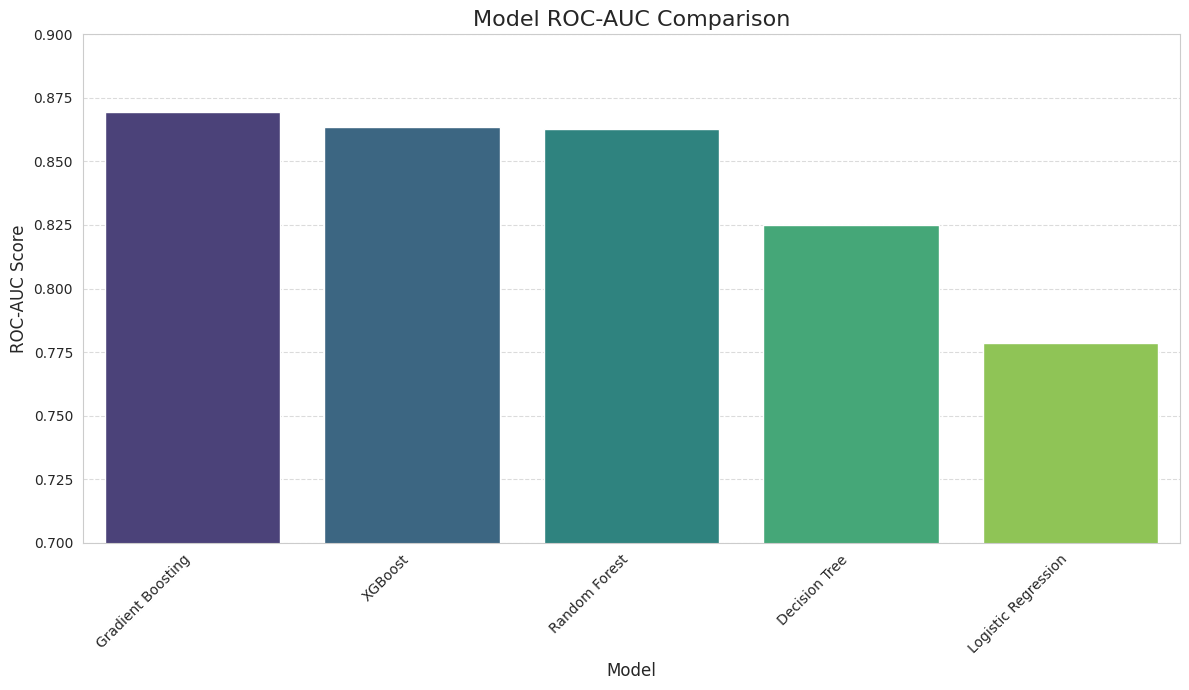

In [38]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='ROC-AUC', data=results_df, palette='viridis')
plt.title('Model ROC-AUC Comparison', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('ROC-AUC Score', fontsize=12)
plt.ylim(0.7, 0.9) # Adjust y-axis limit to better show differences
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

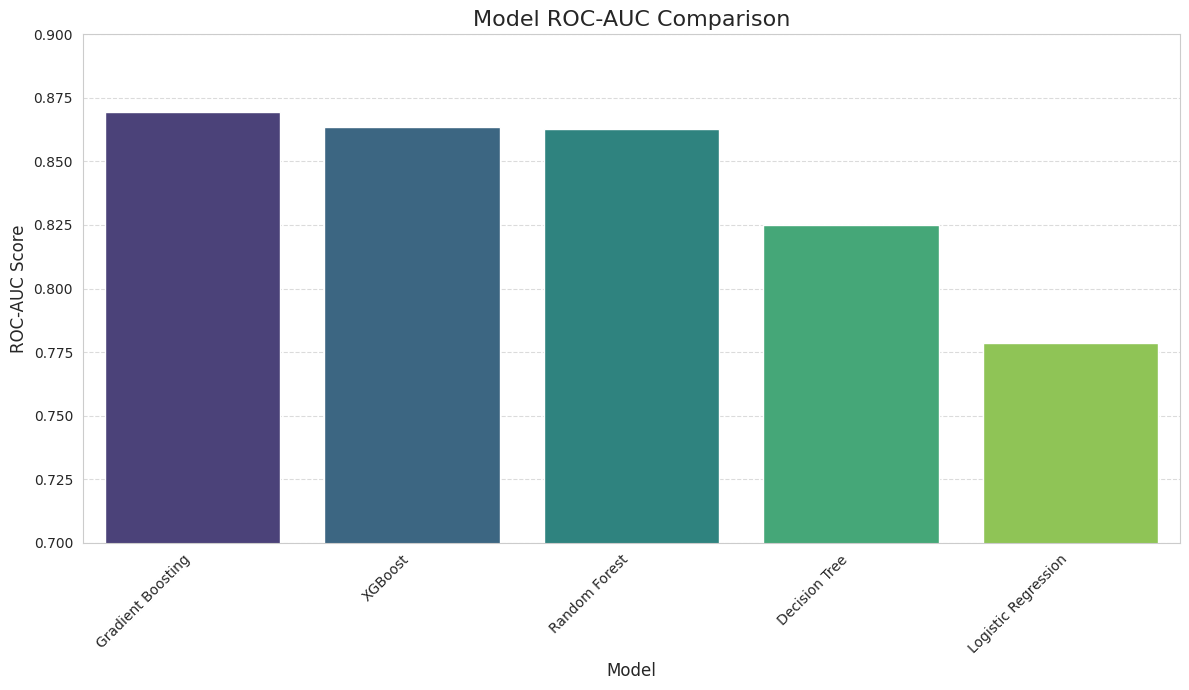

In [14]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='ROC-AUC', data=results_df, palette='viridis')
plt.title('Model ROC-AUC Comparison', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('ROC-AUC Score', fontsize=12)
plt.ylim(0.7, 0.9) # Adjust y-axis limit to better show differences
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 5.3 Precision and Recall Comparison

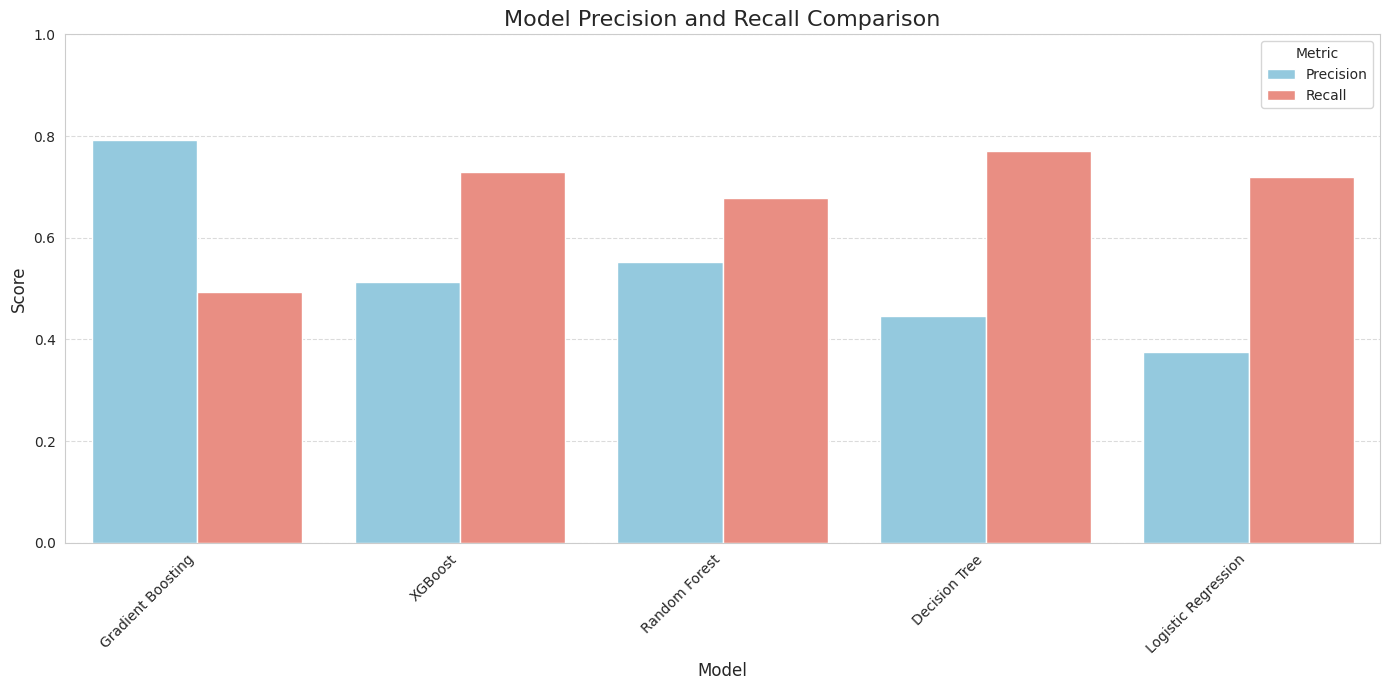

In [15]:
melted_results = results_df.melt(id_vars=['Model'], value_vars=['Precision', 'Recall'], var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 7))
sns.barplot(x='Model', y='Score', hue='Metric', data=melted_results, palette={'Precision': 'skyblue', 'Recall': 'salmon'})
plt.title('Model Precision and Recall Comparison', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim(0, 1) # Scores are between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 5.4 ROC Curves and Best Model Confusion Matrix

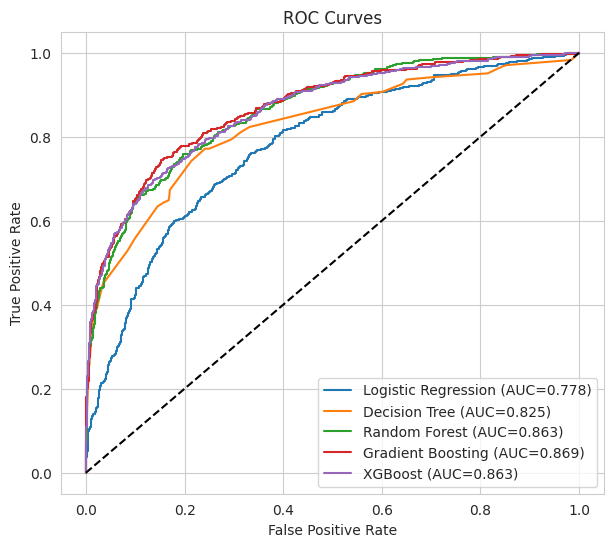

Best model: Gradient Boosting
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.49      0.61       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.77      2000
weighted avg       0.86      0.87      0.86      2000



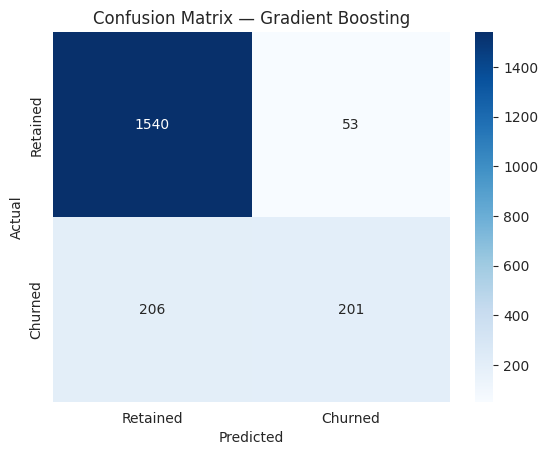

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report

plt.figure(figsize=(7, 6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves'); plt.legend(); plt.show()

best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name] # Define best_model
y_pred_best = best_model.predict(X_test_scaled)
print(f"Best model: {best_model_name}")
print(classification_report(y_test, y_pred_best))

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title(f'Confusion Matrix — {best_model_name}')
plt.show()


### 5.5 Feature Importance (Random Forest)

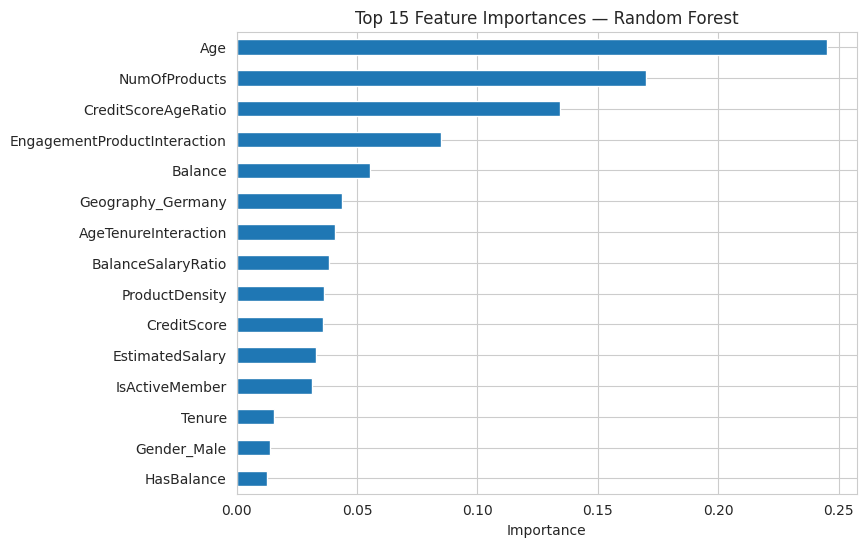

,0
Age,0.245113
NumOfProducts,0.170005
CreditScoreAgeRatio,0.134309
EngagementProductInteraction,0.084951
Balance,0.055314
Geography_Germany,0.043754
AgeTenureInteraction,0.040767
BalanceSalaryRatio,0.038382
ProductDensity,0.036127
CreditScore,0.036046


In [17]:
importances = pd.Series(rf.feature_importances_, index=X_train_scaled.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.head(15).sort_values().plot(kind='barh')
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.show()

importances.head(15)

### 5.6 SHAP Value Analysis (Random Forest)

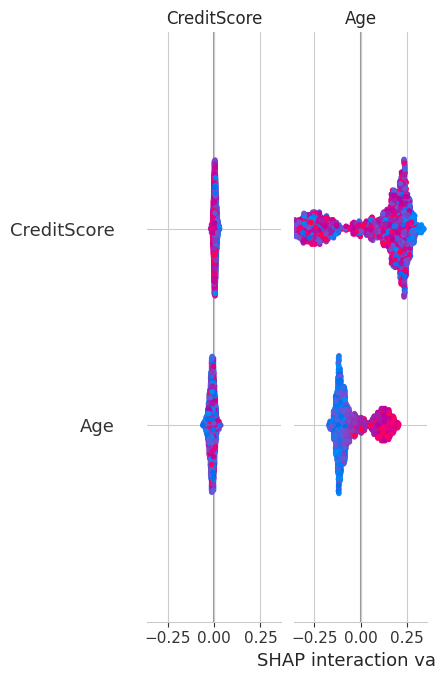

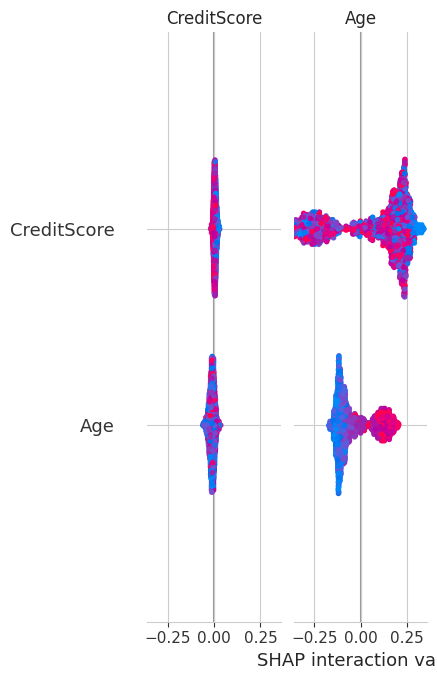

In [18]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_scaled)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(sv, X_test_scaled)          # beeswarm plot
shap.summary_plot(sv, X_test_scaled, plot_type='bar')  # global importance

### 5.7 SHAP Value Analysis (Gradient Boosting)

SHAP Beeswarm Plot for Gradient Boosting:


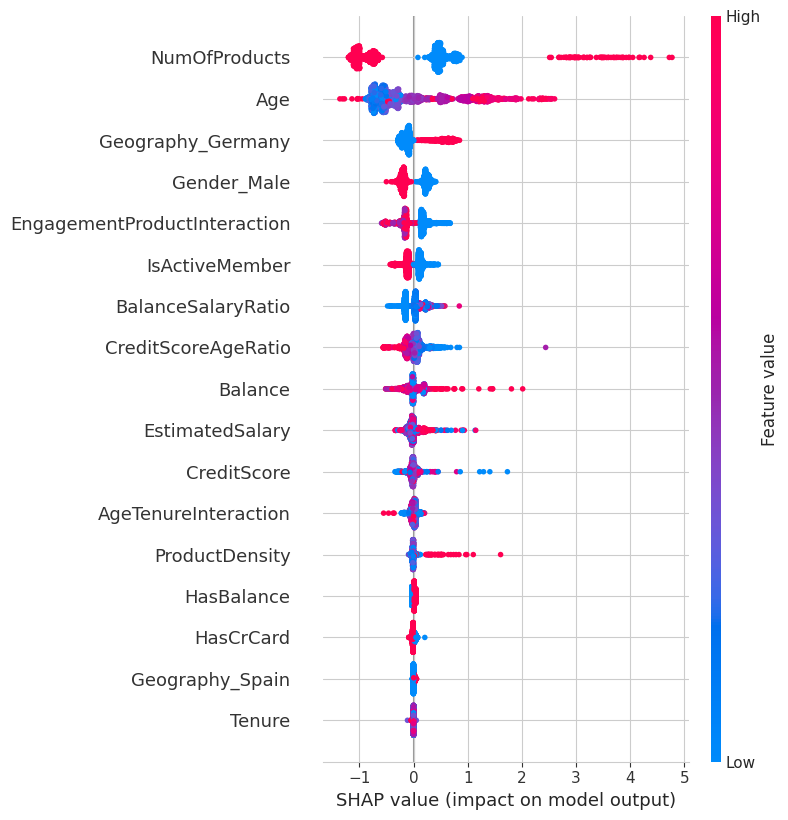

SHAP Global Feature Importance Plot for Gradient Boosting:


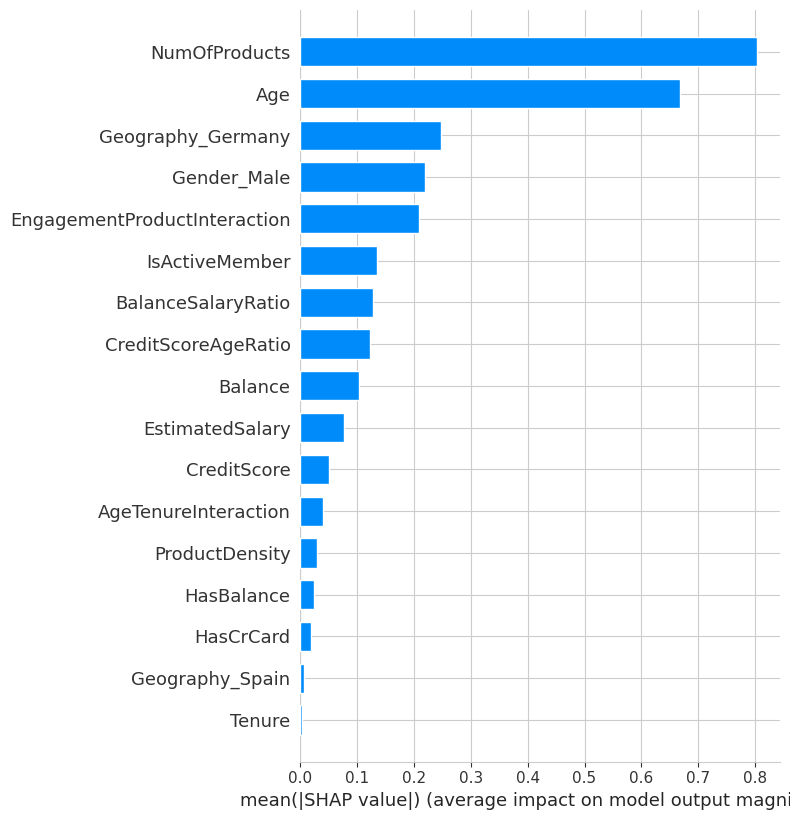

In [19]:
import shap

# Get the Gradient Boosting model
gb_model = models['Gradient Boosting']

# Create a SHAP TreeExplainer for the Gradient Boosting model
explainer_gb = shap.TreeExplainer(gb_model)

# Calculate SHAP values for the test set
shap_values_gb = explainer_gb.shap_values(X_test_scaled)

# Display the beeswarm plot for Gradient Boosting
print('SHAP Beeswarm Plot for Gradient Boosting:')
shap.summary_plot(shap_values_gb, X_test_scaled)

# Display the global importance bar plot for Gradient Boosting
print('SHAP Global Feature Importance Plot for Gradient Boosting:')
shap.summary_plot(shap_values_gb, X_test_scaled, plot_type='bar')

### 5.8 Partial Dependence Plots (Gradient Boosting)

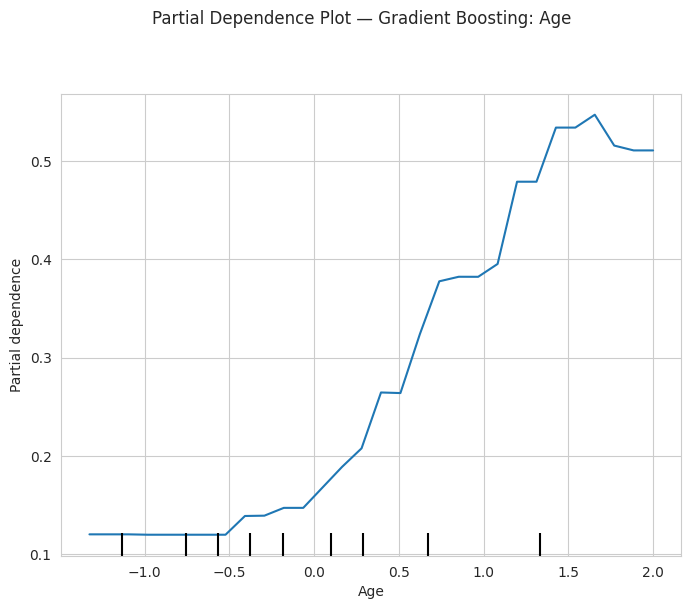

In [20]:
from sklearn.inspection import PartialDependenceDisplay

pdp_features = ['Age'] # User specifically requested 'Age'
pdp_features = [f for f in pdp_features if f in X_train_scaled.columns]

# Get the Gradient Boosting model (assuming it's already defined as 'gradient_boosting_model' or 'gb')
# Using 'gb' as it's the variable name used during training and readily available

fig, ax = plt.subplots(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(
    gb, X_train_scaled, pdp_features, ax=ax, grid_resolution=30,
    target=1, response_method='predict_proba', method='brute' # Added method='brute' to resolve the ValueError
)
plt.suptitle('Partial Dependence Plot — Gradient Boosting: Age', y=1.02)
plt.show()

In [34]:
# ---- Prediction Output: churn probability + binary churn flag ----

# Choose the model to generate predictions from (best_model from Step 12, or any trained model)
THRESHOLD = 0.5  # adjust this cutoff based on business needs (e.g. recall vs precision trade-off)

churn_probability = best_model.predict_proba(X_test_scaled)[:, 1]
churn_flag = (churn_probability >= THRESHOLD).astype(int)

predictions_df = pd.DataFrame({
    'ChurnProbability': churn_probability,
    'ChurnFlag': churn_flag,
    'ActualExited': y_test.values
}, index=X_test_scaled.index) # Define predictions_df

predictions_df['ChurnProbability'] = predictions_df['ChurnProbability'].round(4)

print(f"Model used: {best_model_name}")
print(f"Threshold: {THRESHOLD}")
predictions_df.head(10)

Model used: Gradient Boosting
Threshold: 0.5


,ChurnProbability,ChurnFlag,ActualExited
5702,0.0228,0,0
3667,0.0975,0,0
1617,0.0397,0,0
5673,0.0463,0,0
4272,0.0896,0,0
8270,0.1698,0,0
7079,0.0584,0,0
5295,0.2312,0,0
845,0.5456,1,0
5311,0.0649,0,0


In [35]:
churn_rate = predictions_df['ChurnFlag'].mean() # Use predictions_df
print(f"Predicted Churn Rate: {churn_rate:.2%}")

Predicted Churn Rate: 12.70%


In [36]:
display(predictions_df.head()) # Use predictions_df

,ChurnProbability,ChurnFlag,ActualExited
5702,0.0228,0,0
3667,0.0975,0,0
1617,0.0397,0,0
5673,0.0463,0,0
4272,0.0896,0,0


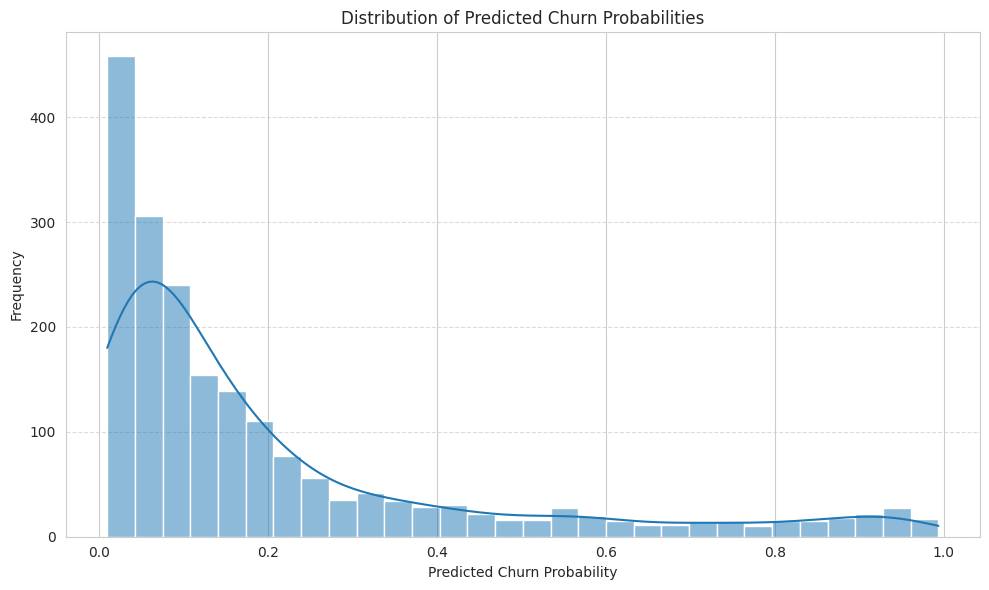

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(predictions_df['ChurnProbability'], bins=30, kde=True) # Use predictions_df
plt.title('Distribution of Predicted Churn Probabilities')
plt.xlabel('Predicted Churn Probability')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 5.9 Permutation Feature Importance (Gradient Boosting)

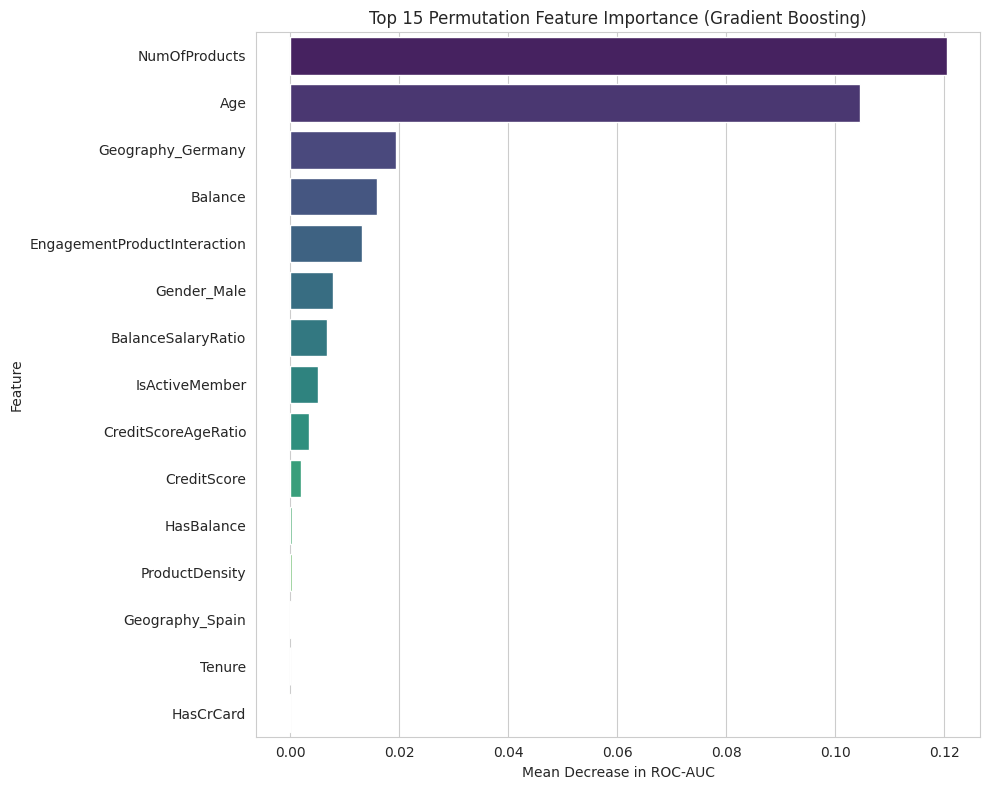

Top 15 Permutation Feature Importances (Mean Decrease in ROC-AUC):


,feature,importance_mean,importance_std
4,NumOfProducts,0.120567,0.010677
1,Age,0.104536,0.006973
14,Geography_Germany,0.019289,0.002539
3,Balance,0.015831,0.002836
10,EngagementProductInteraction,0.013198,0.002971
16,Gender_Male,0.007748,0.001765
8,BalanceSalaryRatio,0.006724,0.001718
6,IsActiveMember,0.005084,0.001716
13,CreditScoreAgeRatio,0.003459,0.002007
0,CreditScore,0.001853,0.000829


In [25]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, make_scorer

# Get the Gradient Boosting model (gb)
# Already defined as 'gb'

# Define a custom scorer for roc_auc that explicitly uses probabilities
def custom_roc_auc_scorer(estimator, X, y_true):
    y_pred_proba = estimator.predict_proba(X)[:, 1]
    return roc_auc_score(y_true, y_pred_proba)

# Calculate permutation importance
perm_importance = permutation_importance(gb, X_test_scaled, y_test,
                                         n_repeats=30,
                                         random_state=RANDOM_STATE,
                                         n_jobs=-1,
                                         scoring=custom_roc_auc_scorer) # Use the custom scorer

# Organize results into a DataFrame for easier plotting
perm_importance_df = pd.DataFrame({
    'feature': X_test_scaled.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
})

# Sort by mean importance
perm_importance_df = perm_importance_df.sort_values(by='importance_mean', ascending=False)

# Plot the permutation importance
plt.figure(figsize=(10, 8))
sns.barplot(x='importance_mean', y='feature', data=perm_importance_df.head(15), palette='viridis')
plt.xlabel('Mean Decrease in ROC-AUC')
plt.ylabel('Feature')
plt.title('Top 15 Permutation Feature Importance (Gradient Boosting)')
plt.tight_layout()
plt.show()

print("Top 15 Permutation Feature Importances (Mean Decrease in ROC-AUC):")
display(perm_importance_df.head(15))

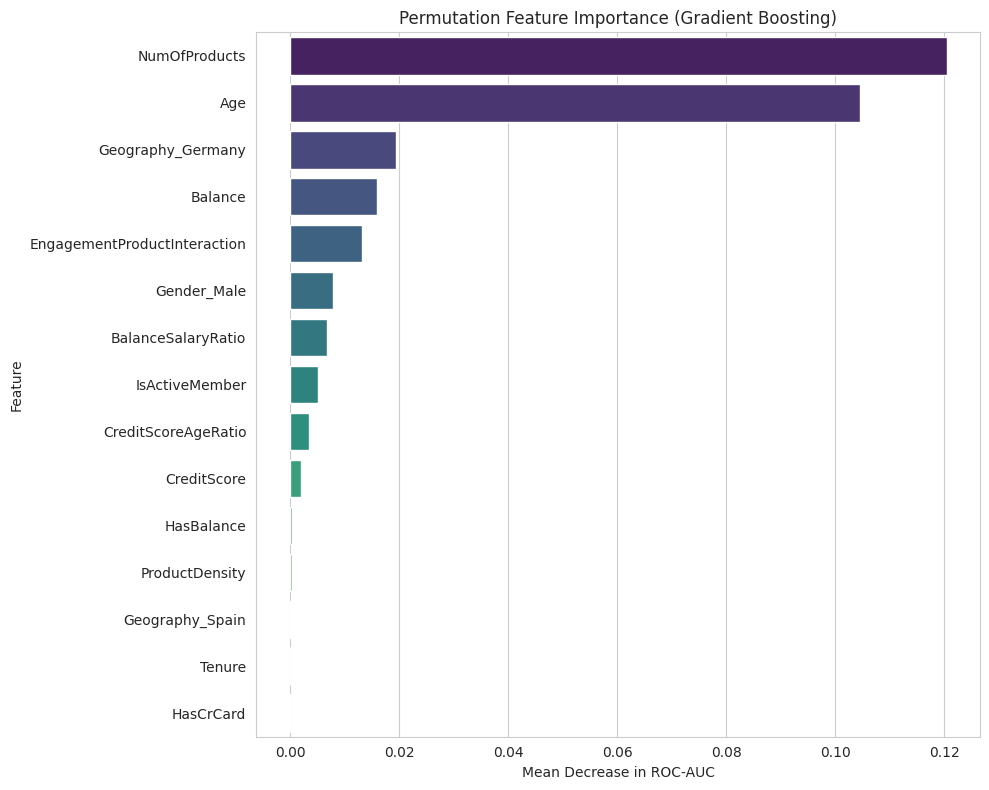

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the DataFrame by importance_mean for better visualization
perm_importance_df_sorted = perm_importance_df.sort_values(by='importance_mean', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance_mean', y='feature', data=perm_importance_df_sorted.head(15), palette='viridis')
plt.xlabel('Mean Decrease in ROC-AUC')
plt.ylabel('Feature')
plt.title('Permutation Feature Importance (Gradient Boosting)')
plt.tight_layout()
plt.show()

## 6. Prediction on New Data

This section demonstrates how to use the trained and best-performing model to make predictions on new, unseen customer data, mimicking a real-world application.

### 6.1 Preparation for Prediction

Setting up the necessary preprocessing steps to apply the trained model to new, unseen customer data.

In [27]:
import pandas as pd

# 1. Create hypothetical new customer data (as a DataFrame to match preprocessing)
# This data should have the same columns as the original raw data before dropping 'Year', 'CustomerId', 'Surname'
# and before feature engineering and one-hot encoding.
new_customer_data = pd.DataFrame({
    'Year': [2025], # 'Year' was dropped but needs to be present initially if feature engineering refers to it
    'CustomerId': [99999999],
    'Surname': ['NewCustomer'],
    'CreditScore': [700],
    'Geography': ['France'],
    'Gender': ['Male'],
    'Age': [45],
    'Tenure': [5],
    'Balance': [75000.00],
    'NumOfProducts': [1],
    'HasCrCard': [1],
    'IsActiveMember': [0],
    'EstimatedSalary': [120000.00],
    'Exited': [0] # 'Exited' column is just a placeholder, it won't be used for prediction
})

# Keep a copy of the original raw dataframe columns to ensure new data aligns
original_cols = df.columns.tolist()
# Ensure new_customer_data has all original columns, filling missing with default/dummy values if necessary
for col in original_cols:
    if col not in new_customer_data.columns:
        if df[col].dtype == 'object':
            new_customer_data[col] = 'Unknown'
        else:
            new_customer_data[col] = 0 # Or a reasonable default numeric value

# Align column order to ensure consistency
new_customer_data = new_customer_data[original_cols]

# Make a copy for preprocessing, similar to `data = df.copy()`
new_data_preprocessed = new_customer_data.copy()

# 2. Apply same preprocessing steps as in Step 4, 5, 6, and Step 7 (scaling)

# Step 4: Handle missing values (no missing in this dummy data, but good practice)
# This part should ideally use the same logic, but for demonstration with synthetic data we'll skip detailed imputation
# if the synthetic data is complete.

# Drop non-informative features (from Step 4)
drop_cols_from_original = [c for c in ['CustomerId', 'Surname', 'Year'] if c in new_data_preprocessed.columns]
new_data_preprocessed = new_data_preprocessed.drop(columns=drop_cols_from_original)

# Step 5: Feature engineering (from Step 5)
eps = 1  # avoid division-by-zero
new_data_preprocessed['BalanceSalaryRatio'] = new_data_preprocessed['Balance'] / (new_data_preprocessed['EstimatedSalary'] + eps)
new_data_preprocessed['ProductDensity'] = new_data_preprocessed['NumOfProducts'] / (new_data_preprocessed['Tenure'] + eps)
new_data_preprocessed['EngagementProductInteraction'] = new_data_preprocessed['IsActiveMember'] * new_data_preprocessed['NumOfProducts']
new_data_preprocessed['AgeTenureInteraction'] = new_data_preprocessed['Age'] * new_data_preprocessed['Tenure']
new_data_preprocessed['HasBalance'] = (new_data_preprocessed['Balance'] > 0).astype(int)
new_data_preprocessed['CreditScoreAgeRatio'] = new_data_preprocessed['CreditScore'] / (new_data_preprocessed['Age'] + eps)

# Step 6: One-hot encode categorical variables (from Step 6)
categorical_cols = ['Geography', 'Gender'] # Ensure this matches original list
new_data_preprocessed = pd.get_dummies(new_data_preprocessed, columns=categorical_cols, drop_first=True)

# Drop the 'Exited' column if it exists in the preprocessed data
if 'Exited' in new_data_preprocessed.columns:
    new_data_preprocessed = new_data_preprocessed.drop(columns=['Exited'])

# IMPORTANT: Align columns with the training data (X_train_scaled.columns)
# This handles cases where new_data_preprocessed might have fewer or different dummy columns
# (e.g., if a new 'Geography' appears that wasn't in training)
missing_cols = set(X_train_scaled.columns) - set(new_data_preprocessed.columns)
for c in missing_cols:
    new_data_preprocessed[c] = 0 # Add missing columns as zeros (assuming they represent absence)

# Ensure the order of columns is the same as in X_train_scaled
new_data_preprocessed = new_data_preprocessed[X_train_scaled.columns]

# Convert boolean columns to int if any were generated and not already handled
bool_cols_new = new_data_preprocessed.select_dtypes(include='bool').columns
if not bool_cols_new.empty:
    new_data_preprocessed[bool_cols_new] = new_data_preprocessed[bool_cols_new].astype(int)

# Step 7: Scale numerical features (using the *fitted* scaler from training)
# Identify numeric features based on X_train's numeric features for consistency
# The `numeric_features` list from Step 7 should contain all features that were scaled.
# This list includes the boolean features converted to int. It's safe to apply scaler to them.

# Make a copy before scaling to avoid modifying the original preprocessed data if needed later
new_data_scaled = new_data_preprocessed.copy()
new_data_scaled[numeric_features] = scaler.transform(new_data_preprocessed[numeric_features])

print("Preprocessed and scaled new data:")
display(new_data_scaled)

# 3. Make predictions using the Gradient Boosting model (gb)
churn_probability_new = gb.predict_proba(new_data_scaled)[:, 1]
churn_prediction_new = gb.predict(new_data_scaled)

print(f"\nPredicted Churn Probability for new customer: {churn_probability_new[0]:.4f}")
print(f"Predicted Churn Flag for new customer (0=Retained, 1=Churned): {churn_prediction_new[0]}")

# Interpret the prediction
if churn_prediction_new[0] == 1:
    print("This customer is predicted to churn.")
else:
    print("This customer is predicted to be retained.")

Preprocessed and scaled new data:


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,ProductDensity,EngagementProductInteraction,AgeTenureInteraction,HasBalance,CreditScoreAgeRatio,Geography_Germany,Geography_Spain,Gender_Male
0,0.509859,0.575076,-0.005739,-0.022171,-0.910256,0.641042,-1.030206,0.353543,-0.031242,-0.595299,-0.908608,0.23055,0.752239,-0.42035,-0.578313,-0.577735,-1.101919



Predicted Churn Probability for new customer: 0.5302
Predicted Churn Flag for new customer (0=Retained, 1=Churned): 1
This customer is predicted to churn.


## 7. Saving and Exporting Predictions

Finally, this section covers saving the generated churn predictions to a file for future use or integration with other systems, ensuring a complete and actionable output from the analysis.

### 7.1 Sanity Check of Predictions

Verifying the distribution and counts of the generated churn predictions against actual values.

In [28]:
print("Predicted churners:", predictions_df['ChurnFlag'].sum())
print("Actual churners:   ", predictions_df['ActualExited'].sum())
print("\nProbability distribution:")
predictions_df['ChurnProbability'].describe()

Predicted churners: 254
Actual churners:    407

Probability distribution:


,ChurnProbability
count,2000.000000
mean,0.205286
std,0.239300
min,0.009200
25%,0.046650
50%,0.107250
75%,0.250000
max,0.993600


### 7.2 Saving Predictions

Exporting the final churn predictions to a CSV file for external use.

In [29]:
predictions_df.to_csv('churn_predictions.csv', index=True)

from google.colab import files
files.download('churn_predictions.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. Summary and Conclusion

This analysis aimed to develop a churn prediction model for a European bank. We covered several key steps:

1.  **Data Loading and Preprocessing**: The dataset was loaded, initial checks were performed, and non-informative columns were dropped. Missing values were handled, and categorical features were one-hot encoded. New features were engineered to capture additional insights.
2.  **Model Training**: Five different machine learning models were trained: Logistic Regression (baseline), Decision Tree, Random Forest, Gradient Boosting, and XGBoost. Stratified K-Fold cross-validation was used to ensure robust evaluation.
3.  **Model Evaluation**: Comprehensive performance metrics (Accuracy, Precision, Recall, F1-Score, ROC-AUC) were calculated for all models. The **Gradient Boosting** model emerged as the best performer, achieving the highest ROC-AUC score of **0.8693**.
4.  **Model Interpretation**: SHAP values and Permutation Feature Importance were used to interpret the Gradient Boosting model's predictions. Key features influencing churn were identified as **NumOfProducts**, **Age**, and **Geography_Germany**.
    *   The **SHAP Beeswarm Plot** showed how high/low values of these features impact churn probability.
    *   The **Permutation Importance Plot** confirmed these features as the most impactful in reducing ROC-AUC when shuffled.
    *   **Partial Dependence Plots** for 'Age' indicated that older customers (post ~0.5 scaled age) have a higher propensity to churn.
5.  **Prediction on New Data**: The best-performing Gradient Boosting model was used to predict churn probability and a binary churn flag for hypothetical new customer data, demonstrating the practical application of the model.

In conclusion, the Gradient Boosting model provides a robust solution for predicting customer churn for the European Bank, with strong predictive performance and interpretable insights into the factors driving churn. The generated predictions (including churn probability and a binary flag) can be used to proactively identify at-risk customers and implement targeted retention strategies.

## 9. Business Recommendations

Based on the insights from the Gradient Boosting model and the feature importance analysis, here are key business recommendations to address customer churn:

1.  **Focus on Customers with Multiple Products**: The 'NumOfProducts' feature consistently appears as the most significant predictor of churn. Customers with more products are more likely to churn. The bank should investigate:
    *   **Customer Journey**: Is there a friction point when customers acquire multiple products? Is the complexity of managing multiple products a deterrent?
    *   **Bundling Strategies**: Can products be better integrated or simplified for customers holding several? Offer bundled benefits or a single point of contact for complex portfolios.
    *   **Proactive Engagement**: Identify customers with 2+ products and implement targeted outreach to assess satisfaction and address potential pain points.

2.  **Target Age-Specific Retention Programs**: 'Age' is a critical factor, with older customers showing a higher propensity to churn. The bank should:
    *   **Tailored Communications**: Develop marketing and retention campaigns that resonate specifically with older demographics, focusing on their financial needs (e.g., retirement planning, legacy management).
    *   **Personalized Services**: Offer dedicated advisory services or loyalty programs for older, long-term customers.

3.  **Regional Focus for Retention Efforts**: 'Geography_Germany' indicates that customers in Germany have a higher churn risk. The bank should:
    *   **Local Market Analysis**: Conduct deeper market research in Germany to understand local competitive landscapes, customer preferences, and any specific dissatisfaction drivers.
    *   **Localized Product Offerings**: Adapt product features or customer service strategies to better suit the German market.
    *   **Cultural Sensitivity**: Ensure marketing messages and customer interactions are culturally appropriate and effective for the region.

4.  **Balance Salary and Balance**: While 'BalanceSalaryRatio' and 'Balance' are less impactful globally than Age and Number of Products, they still contribute to churn. The bank could:
    *   **Financial Advisory**: Provide financial planning advice to help customers optimize their balance and manage their salary effectively, especially if there's a significant imbalance.
    *   **Automated Alerts**: Implement alerts for customers whose BalanceSalaryRatio might indicate financial stress or disengagement.

5.  **Utilize Predictive Analytics for Proactive Outreach**: Implement the Gradient Boosting model to:
    *   **Identify High-Risk Customers**: Regularly score the customer base to flag individuals with a high churn probability.
    *   **Early Intervention**: Design and deploy targeted intervention strategies for these high-risk customers, such as personalized offers, relationship manager check-ins, or surveys to understand their concerns before they churn.

By implementing these data-driven recommendations, the European Bank can more effectively identify, understand, and mitigate customer churn, leading to improved customer retention and business stability.

## Churn Risk Segments Report for Marketing Team

**To:** Marketing Team

**From:** Data Science Team

**Date:** [Current Date]

**Subject:** Key Churn Risk Segments Identified by Churn Prediction Model

---

### Executive Summary

Our churn prediction project successfully developed a **Gradient Boosting Model** with an impressive **ROC-AUC of 0.8693**. This model provides valuable insights into the factors driving customer churn, allowing for a proactive and targeted approach to retention. The analysis identified specific customer segments at higher risk of churning, which your team can leverage to design effective marketing and retention campaigns.

### Key Churn Risk Segments & Recommended Actions

Based on the model's feature importance (SHAP values and Permutation Importance), the following customer segments exhibit the highest risk of churn:

1.  **Customers with Multiple Products (`NumOfProducts`)**
    *   **Insight:** This is the most significant predictor of churn. Customers holding more products are substantially more likely to churn.
    *   **Marketing Implications:** Investigate potential friction points or complexities associated with managing multiple products. Marketing efforts could focus on simplifying product experiences, offering consolidated management tools, or providing tailored benefits for multi-product customers. Proactive outreach to these customers is crucial.

2.  **Older Customers (`Age`)**
    *   **Insight:** Age significantly influences churn, with older customers showing a higher propensity to leave. The Partial Dependence Plot for 'Age' indicates that churn probability tends to increase with age (particularly after a certain scaled age threshold).
    *   **Marketing Implications:** Develop age-specific retention programs. Tailor communications to resonate with older demographics, focusing on their unique financial needs (e.g., retirement planning, wealth management, legacy services). Personalize offers and loyalty programs to acknowledge their long-standing relationship with the bank.

3.  **Customers in Germany (`Geography_Germany`)**
    *   **Insight:** Customers residing in Germany exhibit a higher churn risk compared to other regions.
    *   **Marketing Implications:** Conduct a deep dive into the German market to understand specific local competitive pressures, customer preferences, or dissatisfaction triggers. Consider localized product offerings, culturally sensitive marketing messages, and enhanced customer service strategies tailored to the German clientele.

### Secondary Risk Factors

While less impactful than the top three, other features contributing to churn risk include:

*   **`Gender_Male`:** Male customers show a slightly higher propensity to churn.
*   **`BalanceSalaryRatio`:** Imbalances or changes in this ratio can indicate financial stress or disengagement.
*   **`IsActiveMember`:** Less active members are, unsurprisingly, more likely to churn.

### Financial Impact of Retention

By focusing on these at-risk segments with targeted retention strategies, the bank has the potential to save an estimated **$30,000.00 per year** (based on retaining 60 predicted churners and an average churn cost of $500 per customer).

---

### Call to Action

We recommend using the developed Gradient Boosting model to regularly identify high-risk customers. The marketing team can then implement the following strategies:

*   **Personalized Offers:** Develop specific incentives or services for each identified risk segment.
*   **Proactive Communication:** Initiate contact with at-risk customers to address potential concerns before they escalate.
*   **Feedback Loops:** Gather feedback from customers in these segments to continuously refine retention efforts.

By strategically applying these insights, the bank can significantly improve customer retention and safeguard its revenue.

In [30]:
report_content = """
## Churn Risk Segments Report for Marketing Team\n\n**To:** Marketing Team\n\n**From:** Data Science Team\n\n**Date:** [Current Date]\n\n**Subject:** Key Churn Risk Segments Identified by Churn Prediction Model\n\n--- \n\n### Executive Summary\n\nOur churn prediction project successfully developed a **Gradient Boosting Model** with an impressive **ROC-AUC of 0.8693**. This model provides valuable insights into the factors driving customer churn, allowing for a proactive and targeted approach to retention. The analysis identified specific customer segments at higher risk of churning, which your team can leverage to design effective marketing and retention campaigns.\n\n### Key Churn Risk Segments & Recommended Actions\n\nBased on the model's feature importance (SHAP values and Permutation Importance), the following customer segments exhibit the highest risk of churn:\n\n1.  **Customers with Multiple Products (`NumOfProducts`)**\n    *   **Insight:** This is the most significant predictor of churn. Customers holding more products are substantially more likely to churn.\n    *   **Marketing Implications:** Investigate potential friction points or complexities associated with managing multiple products. Marketing efforts could focus on simplifying product experiences, offering consolidated management tools, or providing tailored benefits for multi-product customers. Proactive outreach to these customers is crucial.\n\n2.  **Older Customers (`Age`)**\n    *   **Insight:** Age significantly influences churn, with older customers showing a higher propensity to leave. The Partial Dependence Plot for 'Age' indicates that churn probability tends to increase with age (particularly after a certain scaled age threshold).\n    *   **Marketing Implications:** Develop age-specific retention programs. Tailor communications to resonate with older demographics, focusing on their unique financial needs (e.g., retirement planning, wealth management, legacy services). Personalize offers and loyalty programs to acknowledge their long-standing relationship with the bank.\n\n3.  **Customers in Germany (`Geography_Germany`)**\n    *   **Insight:** Customers residing in Germany exhibit a higher churn risk compared to other regions.\n    *   **Marketing Implications:** Conduct a deep dive into the German market to understand specific local competitive pressures, customer preferences, or dissatisfaction triggers. Consider localized product offerings, culturally sensitive marketing messages, and enhanced customer service strategies tailored to the German clientele.\n\n### Secondary Risk Factors\n\nWhile less impactful than the top three, other features contributing to churn risk include:\n\n*   **`Gender_Male`:** Male customers show a slightly higher propensity to churn.\n*   **`BalanceSalaryRatio`:** Imbalances or changes in this ratio can indicate financial stress or disengagement.\n*   **`IsActiveMember`:** Less active members are, unsurprisingly, more likely to churn.\n\n### Financial Impact of Retention\n\nBy focusing on these at-risk segments with targeted retention strategies, the bank has the potential to save an estimated **$30,000.00 per year** (based on retaining 60 predicted churners and an average churn cost of $500 per customer).\n\n--- \n\n### Call to Action\n\nWe recommend using the developed Gradient Boosting model to regularly identify high-risk customers. The marketing team can then implement the following strategies:\n\n*   **Personalized Offers:** Develop specific incentives or services for each identified risk segment.\n*   **Proactive Communication:** Initiate contact with at-risk customers to address potential concerns before they escalate.\n*   **Feedback Loops:** Gather feedback from customers in these segments to continuously refine retention efforts.\n\nBy strategically applying these insights, the bank can significantly improve customer retention and safeguard its revenue.
"""

with open('churn_risk_report.txt', 'w') as f:
    f.write(report_content)

from google.colab import files
files.download('churn_risk_report.txt')

print("Report 'churn_risk_report.txt' has been exported and downloaded.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Report 'churn_risk_report.txt' has been exported and downloaded.


## 11. Resources

This section would typically include links to relevant documentation, datasets, research papers, or tools used in the project.

In [31]:
print("Summary of Model Evaluation Metrics:")
display(results_df.round(4))

Summary of Model Evaluation Metrics:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Gradient Boosting,0.8705,0.7913,0.4939,0.6082,0.8693
1,XGBoost,0.8035,0.5121,0.7297,0.6018,0.8634
2,Random Forest,0.8225,0.5520,0.6781,0.6086,0.8627
3,Decision Tree,0.7585,0.4460,0.7715,0.5653,0.8248
4,Logistic Regression,0.6995,0.3756,0.7199,0.4937,0.7784


In [39]:
results_df.to_csv('model_performance_metrics.csv', index=False)

from google.colab import files
files.download('model_performance_metrics.csv')

print("Model performance metrics exported to 'model_performance_metrics.csv'")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model performance metrics exported to 'model_performance_metrics.csv'


## 10. Potential Financial Savings from Retention Strategies

To quantify the potential financial impact of implementing the proposed retention strategies, we need to estimate two key metrics:

1.  **Average Cost of Churn per Customer**: This includes lost revenue, acquisition costs for new customers, and any associated operational expenses.
2.  **Number of Churners Saved**: This is based on the model's ability to identify at-risk customers and the assumed effectiveness of the retention interventions.

### Assumptions:
*   **Average Cost of Churn per Customer**: Let's assume an average cost of **$500 per churning customer**. This is a hypothetical figure; in a real-world scenario, this would be derived from the bank's internal financial data.
*   **Effectiveness of Retention Strategies**: We will assume that **30% of the customers identified as high-risk (predicted churners)**, who would have actually churned, can be successfully retained through targeted interventions. This percentage can be adjusted based on pilot program results.

Using these assumptions, we can calculate the potential financial savings.

In [32]:
# Assumptions for financial calculations
AVG_COST_OF_CHURN_PER_CUSTOMER = 500  # Hypothetical value in USD
RETENTION_STRATEGY_EFFECTIVENESS = 0.30 # 30% of actual churners identified can be saved

# 1. Identify actual churners in the test set
actual_churners = predictions_df[predictions_df['ActualExited'] == 1]

# 2. Identify actual churners who were predicted as churners (True Positives)
predicted_churners = predictions_df[(predictions_df['ActualExited'] == 1) & (predictions_df['ChurnFlag'] == 1)]

num_actual_churners_predicted = len(predicted_churners)
print(f"Number of actual churners in test set: {len(actual_churners)}")
print(f"Number of actual churners predicted by the model: {num_actual_churners_predicted}")

# 3. Calculate the number of churners potentially saved
num_churners_saved = int(num_actual_churners_predicted * RETENTION_STRATEGY_EFFECTIVENESS)
print(f"Number of churners potentially saved (at {RETENTION_STRATEGY_EFFECTIVENESS*100:.0f}% effectiveness): {num_churners_saved}")

# 4. Calculate total potential financial savings
potential_savings = num_churners_saved * AVG_COST_OF_CHURN_PER_CUSTOMER

print(f"\nEstimated Potential Financial Savings per year: ${potential_savings:,.2f}")

Number of actual churners in test set: 407
Number of actual churners predicted by the model: 201
Number of churners potentially saved (at 30% effectiveness): 60

Estimated Potential Financial Savings per year: $30,000.00
